## Project Structure

1. Import Libraries
2. Load Dataset
3. Data Exploration
4. Data Cleaning
5. Sentiment Analysis using TextBlob
6. Visualizations
7. Insights & Business Recommendations

### Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# NLP
from textblob import TextBlob

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
from collections import Counter
import re
from wordcloud import WordCloud

# Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
# Load only first 5000 rows

df = pd.read_csv("Reviews.csv",nrows=5000)

In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Data Exploration

In [4]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [5]:
df.shape

(5000, 10)

In [6]:
review_column = "Text"
rating_column = "Score"

print("Review Text Column:", review_column)
print("Rating Column:", rating_column)

Review Text Column: Text
Rating Column: Score


Data Cleaning

In [7]:
# Keep recquired columns only
df = df[['Text', 'Score']]

In [10]:
df.isnull().sum()

,0
Text,0
Score,0


In [11]:
# empty reviews remove
df = df[df['Text'].str.strip()!= ""]


In [12]:
df = df.drop_duplicates(subset='Text')

In [13]:
# Final Shape
print("Shape after cleaning:", df.shape)

Shape after cleaning: (4984, 2)


Sentiment Analysis

In [16]:
def get_polarity(text):
  return TextBlob(text).sentiment.polarity



In [17]:
df['Polarity'] = df['Text'].apply(get_polarity)

/tmp/ipykernel_540/243943627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Polarity'] = df['Text'].apply(get_polarity)


In [18]:
def classify_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [19]:
df['Sentiment'] = df['Polarity'].apply(classify_sentiment)

/tmp/ipykernel_540/2226922827.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sentiment'] = df['Polarity'].apply(classify_sentiment)


In [20]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,4403
Negative,501
Neutral,80


Visualizarion

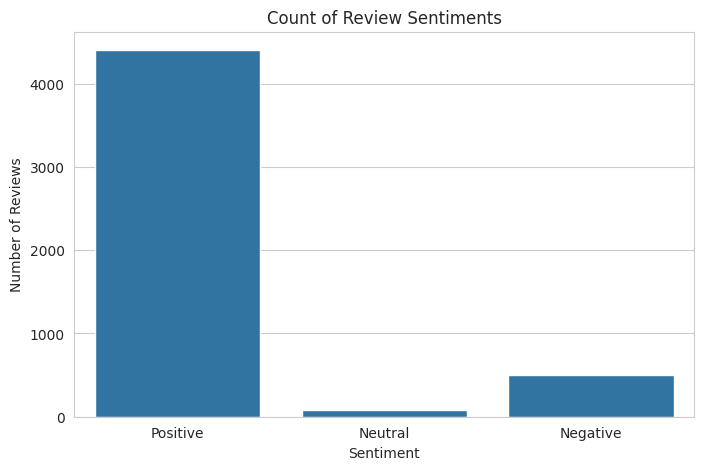

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Sentiment',
    order=['Positive','Neutral','Negative']
)

plt.title("Count of Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

Sentiment Distribution Pie Chart

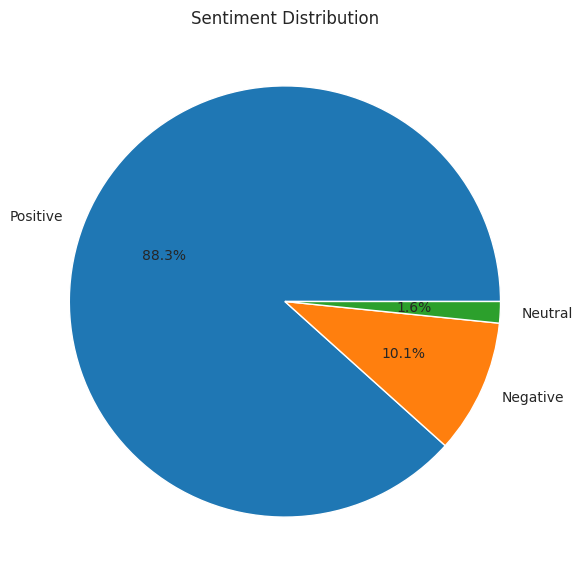

In [22]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution")
plt.show()

Most Common Words in Negative Reviews

In [23]:
negative_reviews = " ".join(
    df[df['Sentiment']=="Negative"]['Text']
)

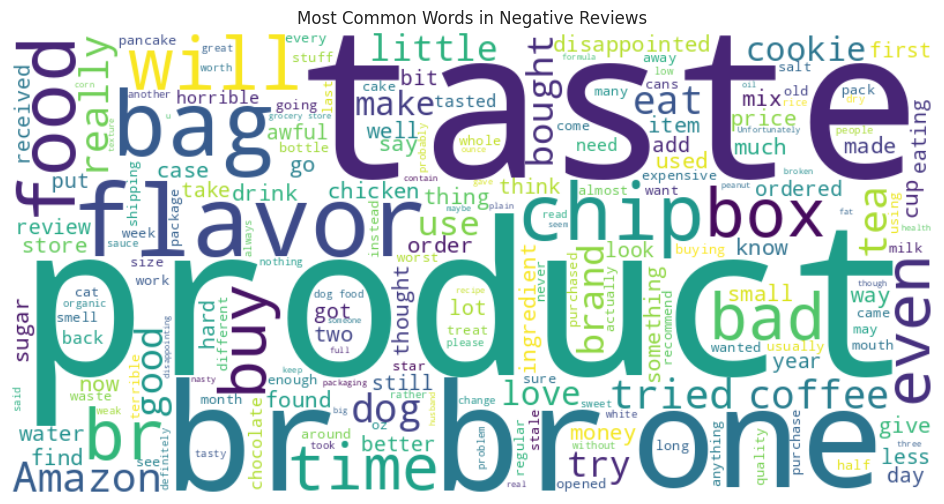

In [24]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()

Rating vs Sentiment

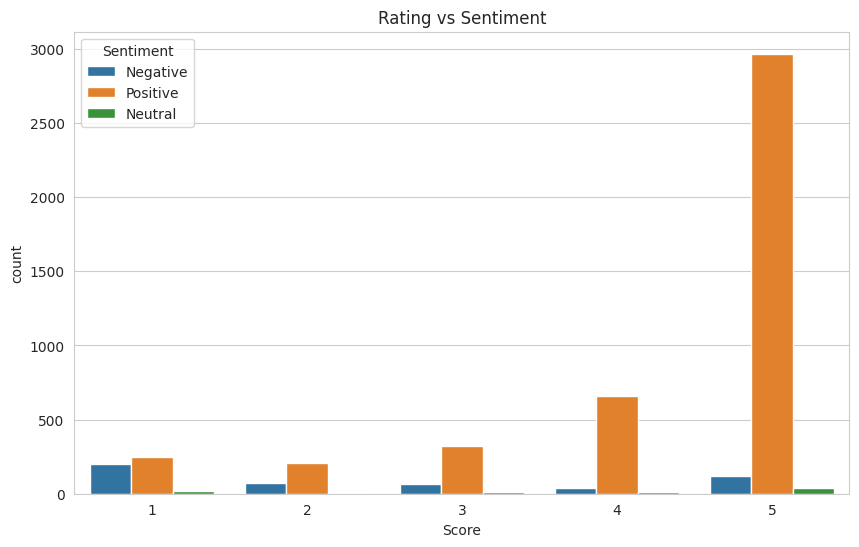

In [25]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Score',
    hue='Sentiment'
)

plt.title("Rating vs Sentiment")
plt.show()

Statistics Percentage

In [26]:
sentiment_percentages = (
    df['Sentiment']
    .value_counts(normalize=True)
    * 100
)

print(sentiment_percentages)

Sentiment
Positive    88.342697
Negative    10.052167
Neutral      1.605136
Name: proportion, dtype: float64


In [27]:
df.groupby('Score')['Polarity'].mean()

,Polarity
Score,
1,-0.011740
2,0.088294
3,0.162130
4,0.244881
5,0.308430


What percentage of reviews are positive?

- Out of the analyzed reviews, approximately 88.3% were classified as positive, indicating that most customers were generally satisfied with the products.

What do customers mostly complain about in negative reviews?

- Negative reviews frequently contained words related to taste, packaging, freshness, delivery issues, and product quality.

What surprised you in the data?

- One interesting observation was that some reviews with high ratings still contained mildly negative language, highlighting limitations of rule-based sentiment analysis. The majority of customers expressed appreciation for product quality and value for money.

One recommendation for the business based on your findings

- Based on these findings, the business should focus on improving packaging consistency and addressing recurring quality complaints. Monitoring negative reviews regularly can help identify product issues before they affect a larger customer base.